# **01 - Linear Regression**

This notebook constructs a multiple linear regression (MLR) model based on real estate valuation from Taipei, Taiwan for an 11-month period from 2012 to 2013. The data contains 6 features with Y being the Price Per Area (Unit of measurement). The dataset contains 414 observations. The training, validation, and test splits were calculated using an 80/20 split.

Training observations: 264
Validation: 67
Test: 83

## ****Libraries****

In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

## **Data Loading**

In [47]:
df = pd.read_excel('datasets/Real estate valuation data set.xlsx')
cleaned_data = df.drop(columns=['No'])

# Training+Validation / Test Split
train_val_df, test_df = train_test_split(
    cleaned_data,
    test_size=0.20, # 80% training+validation / 20% test
    random_state = 499
)

# Training / Validation Split
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20, # 80% training / 20% validation
    random_state=499
)

# X / Y Split
x_train_df = train_df.drop(columns=['Y house price of unit area'])
y_train_df = train_df[['Y house price of unit area']]

x_val_df = val_df.drop(columns=['Y house price of unit area'])
y_val_df = val_df[['Y house price of unit area']]

x_test_df = test_df.drop(columns=['Y house price of unit area'])
y_test_df = test_df[['Y house price of unit area']]

# Feature Scaling
x_train_mean = x_train_df.mean()
x_train_std = x_train_df.std()

x_train_scaled = (x_train_df - x_train_mean) / x_train_std
x_val_scaled = (x_val_df - x_train_mean) / x_train_std
x_test_scaled = (x_test_df - x_train_mean) / x_train_std

# Check Scaling
print(x_train_scaled.mean())
print(x_train_scaled.std())

# Convert data into Tensor Data
x_train = torch.tensor(x_train_scaled.values, dtype=torch.float32)
y_train = torch.tensor(y_train_df.values, dtype=torch.float32)

x_val = torch.tensor(x_val_scaled.values, dtype=torch.float32)
y_val = torch.tensor(y_val_df.values, dtype=torch.float32)

x_test = torch.tensor(x_test_scaled.values, dtype=torch.float32)
y_test = torch.tensor(y_test_df.values, dtype=torch.float32)

# Check Shape
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

torch.Size([264, 6]) torch.Size([264, 1])
torch.Size([67, 6]) torch.Size([67, 1])
torch.Size([83, 6]) torch.Size([83, 1])
X1 transaction date                      -3.595743e-13
X2 house age                              2.018587e-16
X3 distance to the nearest MRT station   -8.747212e-17
X4 number of convenience stores           5.382900e-17
X5 latitude                              -1.336641e-13
X6 longitude                             -1.213084e-12
dtype: float64
X1 transaction date                       1.0
X2 house age                              1.0
X3 distance to the nearest MRT station    1.0
X4 number of convenience stores           1.0
X5 latitude                               1.0
X6 longitude                              1.0
dtype: float64


## **Model**

### **Model Architecture**

In [73]:
# Linear Regression Architecture
class LR(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(input_features, 1)
        )

    def forward(self, data):
        prediction = self.linear_stack(data)
        return prediction

# Instance, Loss Function, Optimizer
model = LR(6) # Specify number of features
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=1e-2) #Stochastic Grad. Descent

### **Model Training and Validation**

epoch =  0  training loss =  1102.2645263671875  validation loss =  1186.9041748046875  difference =  84.6396484375
epoch =  1  training loss =  784.903564453125  validation loss =  873.9225463867188  difference =  89.01898193359375
epoch =  2  training loss =  561.0546875  validation loss =  653.3240356445312  difference =  92.26934814453125
epoch =  3  training loss =  410.8791809082031  validation loss =  501.62921142578125  difference =  90.75003051757812
epoch =  4  training loss =  304.05841064453125  validation loss =  394.6456298828125  difference =  90.58721923828125
epoch =  5  training loss =  231.67564392089844  validation loss =  321.4117431640625  difference =  89.73609924316406
epoch =  6  training loss =  180.06175231933594  validation loss =  268.3043518066406  difference =  88.24259948730469
epoch =  7  training loss =  143.99717712402344  validation loss =  232.06353759765625  difference =  88.06636047363281
epoch =  8  training loss =  118.625244140625  validation l

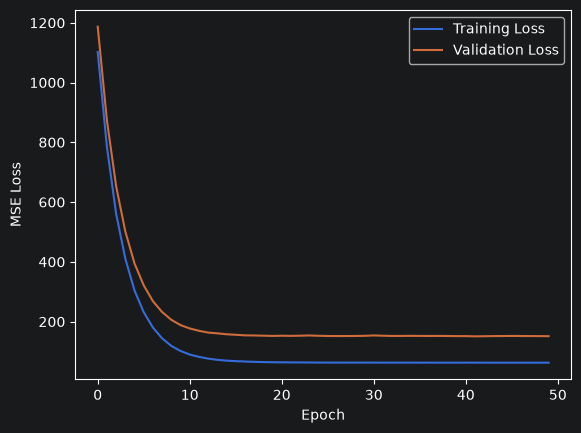

In [74]:
loss_list = []
val_loss_list = []
nums_epoch = 50 # Epoch is one complete pass through the training set

merged_training = TensorDataset(x_train, y_train)
train_loader = DataLoader(merged_training, batch_size=32, shuffle=True)

for epoch in range(nums_epoch):

    for x_batch, y_batch in train_loader:

        prediction = model(x_batch) # Takes x training data, produces new y_hat with current parameters
        loss = loss_function(prediction, y_batch) # Cost/Loss function calculation

        # Gradient Descent
        optimizer.zero_grad() # Clear current gradient information
        loss.backward() # Backprop - calculate partial derivatives based on current loss with respect to each contributing parameter
        optimizer.step() # Calculate the new weights based on step/learning rate

    # Training loss for the completed epoch
    train_prediction = model(x_train)
    train_loss = loss_function(train_prediction, y_train)
    loss_list.append(train_loss.item())

    # Validation loss for the completed epoch
    val_prediction = model(x_val)
    val_loss = loss_function(val_prediction, y_val)
    val_loss_list.append(val_loss.item())

    if epoch % 1 == 0:
        print('epoch = ', epoch,
              ' training loss = ', train_loss.item(),
              ' validation loss = ', val_loss.item(),
              ' difference = ', abs(train_loss.item()-val_loss.item())
        )

# Training Error vs Validation Error Plot
plt.plot(loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

### **Model Testing**

In [75]:
model.eval()

with torch.no_grad():
    test_prediction = model(x_test)
    test_loss = loss_function(test_prediction, y_test)

print("Test MSE = ", test_loss.item())


Test MSE =  68.03048706054688


## **Results**

**Results**: briefly state what the finished model actually did. You already have useful evidence:
- Training MSE ≈ 62–63
- Validation MSE ≈ 151
- Test MSE ≈ 68
- Training and validation loss dropped rapidly and mostly converged by roughly 20 epochs
- Validation behaved substantially differently from test

**What I learned:**
